# Hormuz disruption → price scenarios

Thin interactive wrapper over `src/oil_models`. See `docs/` for the methodology and `reports/RESULTS.md` for the full generated results.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from oil_models import data_prep, hormuz, kilian_var as kv, scenarios, evaluate, benchmarks, regression, combine, volatility, external_data

In [2]:
full = data_prep.load_kilian_dataset()
m = kv.fit(full[data_prep.VAR_COLUMNS])
hm = hormuz.build_processed()
scenarios.monthly_supply_loss_pct(hm)

date
2026-03-01    23.632563
2026-04-01    23.553271
2026-05-01    19.942653
Freq: MS, dtype: float64

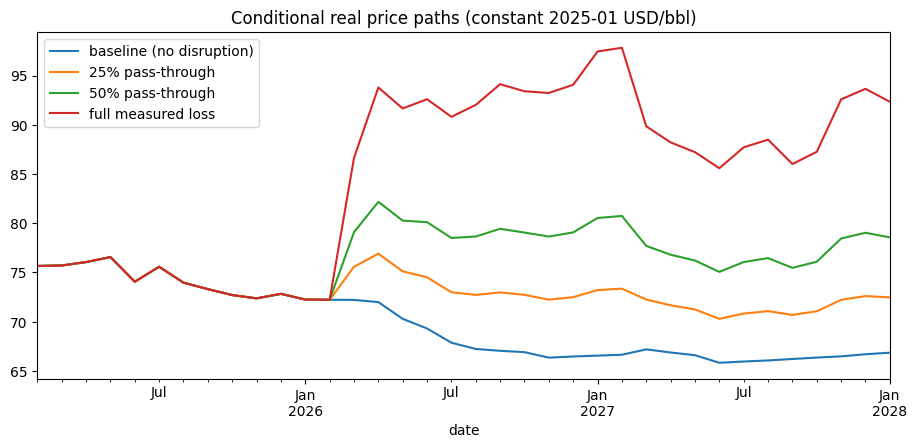

In [3]:
paths = scenarios.run_scenarios(m, hm, horizon=36, ref_cpi=float(full['us_cpi'].iloc[-1]))
paths.plot(figsize=(11,4.5), title='Conditional real price paths (constant 2025-01 USD/bbl)');

In [4]:
scenarios.scenario_summary(paths, hm)

,peak_price_uplift_pct,peak_month,uplift_12m_after_shock_pct
scenario,,,
25% pass-through,10.075215,2027-02,8.411919
50% pass-through,21.165529,2027-02,17.531442
full measured loss,46.810855,2027-02,38.136399


## With a 1990-sized precautionary demand overlay

In [5]:
paths_p = scenarios.run_scenarios(m, hm, horizon=36, ref_cpi=float(full['us_cpi'].iloc[-1]), precautionary_sd=3.4)
scenarios.scenario_summary(paths_p, hm)

,peak_price_uplift_pct,peak_month,uplift_12m_after_shock_pct
scenario,,,
25% pass-through,53.944814,2026-05,25.533658
50% pass-through,64.513164,2026-05,36.093448
full measured loss,87.876232,2026-05,59.952593
